# 📊 EDA: 낚시성 기사 탐지 데이터 탐색적 분석

> **대상 데이터**: `work_pool` (291,466건) — `test_final`은 봉인  
> **데이터 출처**: AI Hub 146 "낚시성 기사 탐지 데이터" 1세부  
> **분석 목적**: 전처리 설계 검증 및 모델링 전략 수립  
> **작성일**: 2026-04-10

In [1]:
# 라이브러리 및 데이터 로딩
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import re
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정 (koreanize-matplotlib)
import koreanize_matplotlib
mpl.rcParams['figure.dpi'] = 120

# work_pool parquet 로딩 (3개 파일 합치기)
df = pd.concat([
    pd.read_parquet('data/processed/work_pool_clickbait_auto.parquet'),
    pd.read_parquet('data/processed/work_pool_clickbait_direct.parquet'),
    pd.read_parquet('data/processed/work_pool_nonclickbait_auto.parquet'),
], ignore_index=True)

print(f'work_pool 총 건수: {len(df):,}')
print(f'컬럼: {list(df.columns)}')
df.head(3)

work_pool 총 건수: 291,466
컬럼: ['newsID', 'newTitle', 'newsContent', 'binary_label', 'type_label', 'source_class', 'title_clean', 'content_clean']


,newsID,newTitle,newsContent,binary_label,type_label,source_class,title_clean,content_clean
0,LC_M03_089986,RM이 부산서 본 이 전시 ...볼탕스키 작품이 말하는 것들,흉터는 의사들이 그다지 달가워하지 않는 시술이다.\n특별한 치료법이 없어 환자의 만...,1,-1,clickbait_auto,RM이 부산서 본 이 전시 ...볼탕스키 작품이 말하는 것들,흉터는 의사들이 그다지 달가워하지 않는 시술이다. 특별한 치료법이 없어 환자의 만족...
1,GB_M11_057148,"오미크론 250명 입원에도…英 당국 \""규제 계획 없어\""",미국 질병통제예방센터(CDC)가 모더나와 얀센 신종 코로나바이러스 감염증(코로나19...,1,-1,clickbait_auto,"오미크론 250명 입원에도…英 당국 \""규제 계획 없어\""",미국 질병통제예방센터(CDC)가 모더나와 얀센 신종 코로나바이러스 감염증(코로나19...
2,PO_M08_105090,"尹 '원전 안전성' 인터뷰 논란에 캠프 \""의미 다르게 전달됐다\""",북한이 12일 동해상으로 탄도미사일을 발사하며 윤석열정부 출범 이틀 만에 첫 무력도...,1,-1,clickbait_auto,"尹 '원전 안전성' 인터뷰 논란에 캠프 \""의미 다르게 전달됐다\""",북한이 12일 동해상으로 탄도미사일을 발사하며 윤석열정부 출범 이틀 만에 첫 무력도...


## 1. 이진 분류 클래스 분포 (낚시성 vs 정상)

이진 분류의 양성(낚시성)과 음성(정상) 비율을 확인한다. 균형 여부에 따라 `class_weight` 적용 여부가 결정된다.

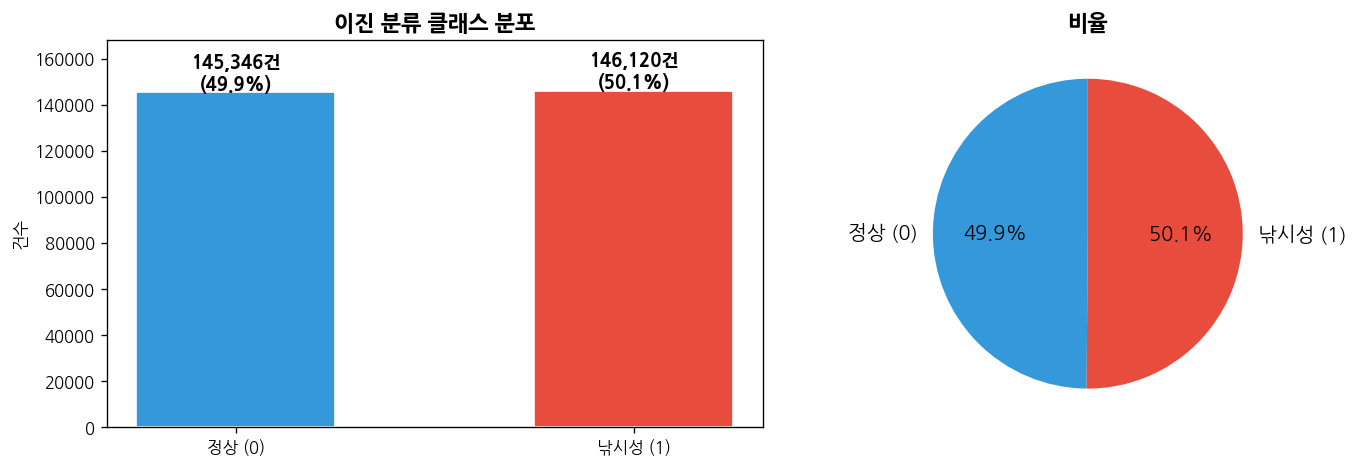

In [2]:
# 이진 분류 클래스 분포
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 1-1. 바 차트
binary_counts = df['binary_label'].value_counts().sort_index()
labels = ['정상 (0)', '낚시성 (1)']
colors = ['#3498db', '#e74c3c']
axes[0].bar(labels, binary_counts.values, color=colors, edgecolor='white', width=0.5)
for i, v in enumerate(binary_counts.values):
    axes[0].text(i, v + 1000, f'{v:,}건\n({v/len(df)*100:.1f}%)', ha='center', fontsize=11, fontweight='bold')
axes[0].set_title('이진 분류 클래스 분포', fontsize=13, fontweight='bold')
axes[0].set_ylabel('건수')
axes[0].set_ylim(0, max(binary_counts.values) * 1.15)

# 1-2. 파이 차트
axes[1].pie(binary_counts.values, labels=labels, colors=colors, autopct='%1.1f%%',
            startangle=90, textprops={'fontsize': 12})
axes[1].set_title('비율', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

### 해석

- **정상 145,346건(49.9%) / 낚시성 146,120건(50.1%)** — 거의 완벽한 1:1 균형.
- 차이가 774건(0.2%p)에 불과하여 `class_weight` 조정 없이 바로 학습해도 무방하다.
- 이진 분류에서 클래스 불균형은 이슈가 아님. 모델이 다수 클래스에 편향될 위험 없음.

## 2. 다중 분류 유형 분포 (6개 유형, Clickbait_Direct만)

다중 분류에 사용되는 Clickbait_Direct 데이터의 6개 유형 분포를 확인한다. 불균형이 심하면 `class_weight='balanced'` 적용이 필요하다.

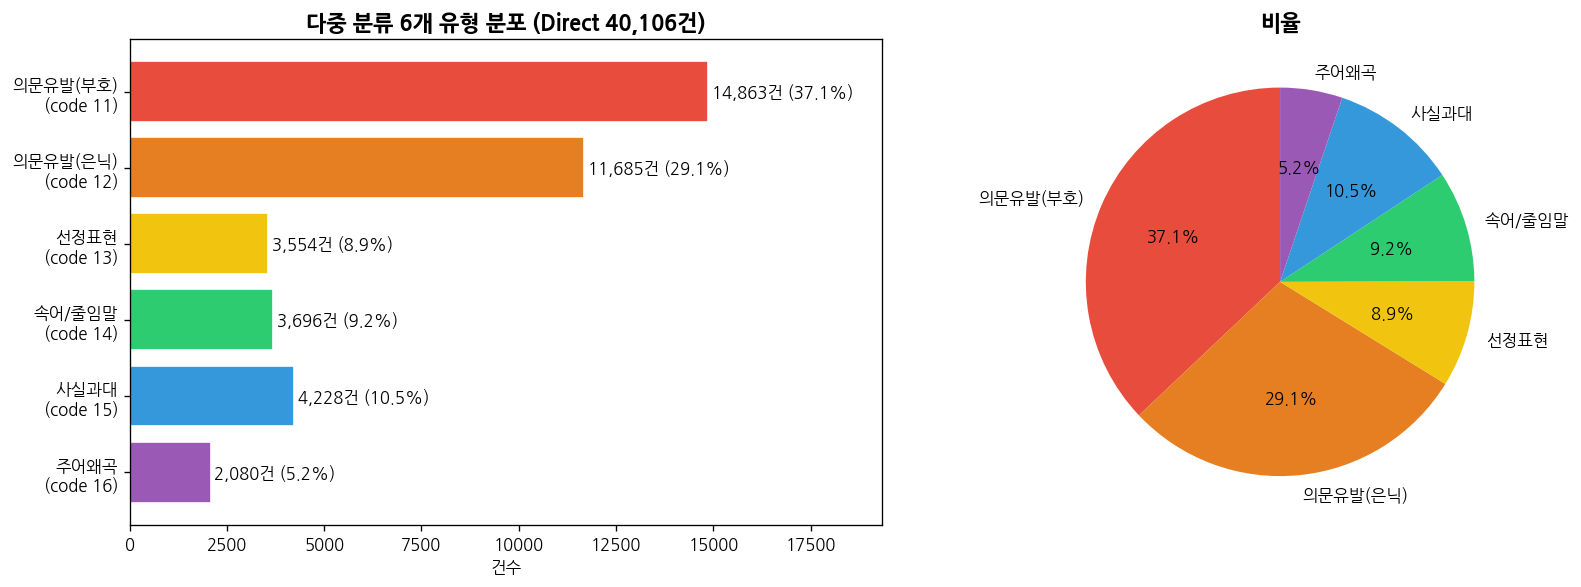

최대(의문유발 부호): 14,863건 / 최소(주어왜곡): 2,080건
불균형 비율: 7.1배


In [3]:
# 다중 분류 유형 분포 (Direct만)
df_direct = df[df['type_label'] >= 0].copy()

TYPE_NAMES = {
    0: '의문유발(부호)', 1: '의문유발(은닉)', 2: '선정표현',
    3: '속어/줄임말', 4: '사실과대', 5: '주어왜곡'
}

type_counts = df_direct['type_label'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 2-1. 수평 바 차트
type_labels = [f'{TYPE_NAMES[i]}\n(code {i+11})' for i in type_counts.index]
colors_6 = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#3498db', '#9b59b6']
bars = axes[0].barh(type_labels, type_counts.values, color=colors_6, edgecolor='white')
for bar, v in zip(bars, type_counts.values):
    axes[0].text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
                f'{v:,}건 ({v/len(df_direct)*100:.1f}%)', va='center', fontsize=10)
axes[0].set_title('다중 분류 6개 유형 분포 (Direct 40,106건)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('건수')
axes[0].invert_yaxis()
axes[0].set_xlim(0, max(type_counts.values) * 1.3)

# 2-2. 파이 차트
type_labels_short = [TYPE_NAMES[i] for i in type_counts.index]
axes[1].pie(type_counts.values, labels=type_labels_short, colors=colors_6,
            autopct='%1.1f%%', startangle=90, textprops={'fontsize': 10})
axes[1].set_title('비율', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

print(f'최대(의문유발 부호): {type_counts[0]:,}건 / 최소(주어왜곡): {type_counts[5]:,}건')
print(f'불균형 비율: {type_counts[0]/type_counts[5]:.1f}배')

### 해석

- **의문유발(부호)가 37.1%로 최대**, 주어왜곡이 5.2%로 최소 → 약 **7배 불균형**.
- 의문유발 계열(부호+은닉) 합치면 **66.2%**로 전체의 2/3를 차지.
- 다중 분류 학습 시 `class_weight='balanced'` 적용이 필수.
- 의문유발(부호) vs 의문유발(은닉) 구분이 모델의 핵심 난이도가 될 것 — confusion matrix에서 중점 관찰 필요.

## 3. 제목 길이 분포

모델 입력인 `newTitle`(라벨러가 만든 제목)의 글자 수 분포를 확인한다. 낚시성과 정상의 제목 길이 차이가 있는지도 비교한다.

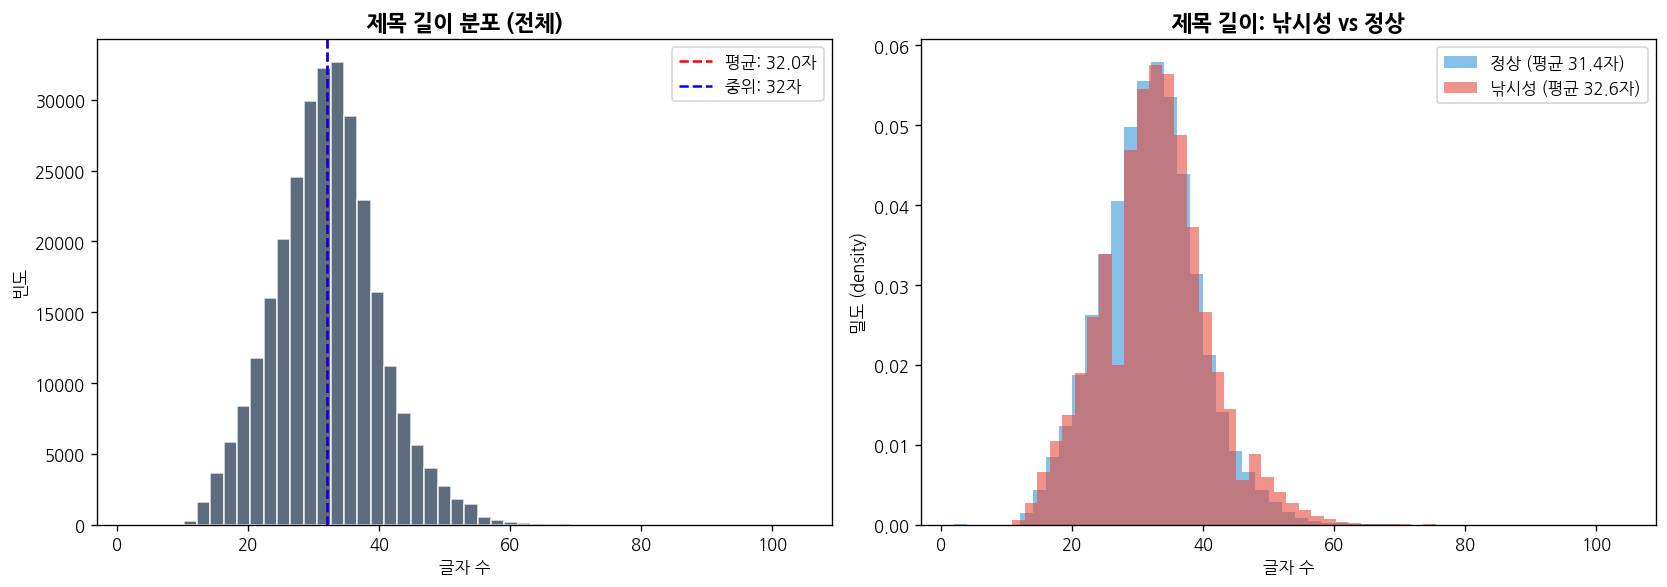

전체 — 평균: 32.0 / 중위: 32 / 최소: 2 / 최대: 104
정상 — 평균: 31.4
낚시 — 평균: 32.6


In [4]:
# 제목 길이 분포
df['title_len'] = df['title_clean'].str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 3-1. 전체 히스토그램
axes[0].hist(df['title_len'], bins=50, color='#34495e', edgecolor='white', alpha=0.8)
axes[0].axvline(df['title_len'].mean(), color='red', linestyle='--', label=f"평균: {df['title_len'].mean():.1f}자")
axes[0].axvline(df['title_len'].median(), color='blue', linestyle='--', label=f"중위: {df['title_len'].median():.0f}자")
axes[0].set_title('제목 길이 분포 (전체)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('글자 수')
axes[0].set_ylabel('빈도')
axes[0].legend(fontsize=10)

# 3-2. 낚시성 vs 정상 비교
df_cb = df[df['binary_label'] == 1]
df_nc = df[df['binary_label'] == 0]
axes[1].hist(df_nc['title_len'], bins=50, alpha=0.6, color='#3498db', label=f"정상 (평균 {df_nc['title_len'].mean():.1f}자)", density=True)
axes[1].hist(df_cb['title_len'], bins=50, alpha=0.6, color='#e74c3c', label=f"낚시성 (평균 {df_cb['title_len'].mean():.1f}자)", density=True)
axes[1].set_title('제목 길이: 낚시성 vs 정상', fontsize=13, fontweight='bold')
axes[1].set_xlabel('글자 수')
axes[1].set_ylabel('밀도 (density)')
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.show()

print(f'전체 — 평균: {df["title_len"].mean():.1f} / 중위: {df["title_len"].median():.0f} / 최소: {df["title_len"].min()} / 최대: {df["title_len"].max()}')
print(f'정상 — 평균: {df_nc["title_len"].mean():.1f}')
print(f'낚시 — 평균: {df_cb["title_len"].mean():.1f}')

### 해석

- **전체 평균 32.0자, 중위수 31자** — 제목이 매우 짧아 BERT 토큰 제한(512)에는 전혀 문제 없음.
- **정상 31.4자 vs 낚시성 32.6자** — 차이가 **1.2자에 불과**하여 제목 길이 자체는 분류에 유의미한 피처가 아님.
- 분포 형태도 거의 동일한 종(bell) 모양으로, 낚시성 여부와 제목 길이 사이에 뚜렷한 패턴이 없음.
- 따라서 모델은 **길이가 아닌 제목의 내용(단어 선택, 부호 사용 등)**에서 분류 단서를 학습해야 함.

## 4. 본문 길이 분포

BERT 모델은 최대 512 토큰까지 입력 가능하다. 한국어 기준 약 1,000~1,500자에 해당한다. 본문이 이를 초과하는 비율을 확인하여 truncation 전략을 수립한다.

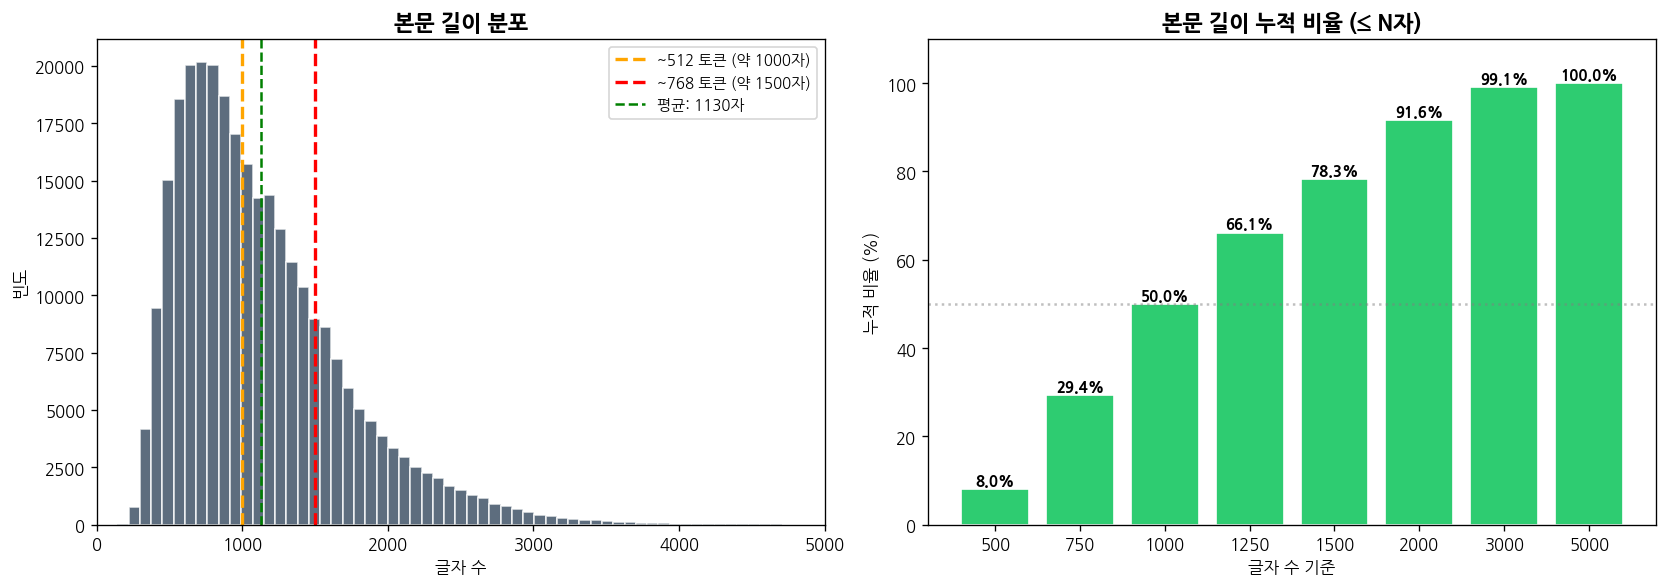

본문 통계 — 평균: 1130자 / 중위: 1001자 / 최대: 6336자
1000자 초과: 145,835건 (50.0%)
1500자 초과: 63,314건 (21.7%)


In [5]:
# 본문 길이 분포
df['body_len'] = df['content_clean'].str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 4-1. 전체 히스토그램 + BERT 기준선
axes[0].hist(df['body_len'], bins=80, color='#34495e', edgecolor='white', alpha=0.8)
axes[0].axvline(1000, color='orange', linestyle='--', linewidth=2, label='~512 토큰 (약 1000자)')
axes[0].axvline(1500, color='red', linestyle='--', linewidth=2, label='~768 토큰 (약 1500자)')
axes[0].axvline(df['body_len'].mean(), color='green', linestyle='--', label=f"평균: {df['body_len'].mean():.0f}자")
axes[0].set_title('본문 길이 분포', fontsize=13, fontweight='bold')
axes[0].set_xlabel('글자 수')
axes[0].set_ylabel('빈도')
axes[0].legend(fontsize=9)
axes[0].set_xlim(0, 5000)

# 4-2. 구간별 누적 비율
thresholds = [500, 750, 1000, 1250, 1500, 2000, 3000, 5000]
ratios = [(df['body_len'] <= t).mean() * 100 for t in thresholds]
axes[1].bar([str(t) for t in thresholds], ratios, color='#2ecc71', edgecolor='white')
for i, (t, r) in enumerate(zip(thresholds, ratios)):
    axes[1].text(i, r + 1, f'{r:.1f}%', ha='center', fontsize=9, fontweight='bold')
axes[1].set_title('본문 길이 누적 비율 (≤ N자)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('글자 수 기준')
axes[1].set_ylabel('누적 비율 (%)')
axes[1].set_ylim(0, 110)
axes[1].axhline(50, color='gray', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

print(f'본문 통계 — 평균: {df["body_len"].mean():.0f}자 / 중위: {df["body_len"].median():.0f}자 / 최대: {df["body_len"].max()}자')
print(f'1000자 초과: {(df["body_len"]>1000).sum():,}건 ({(df["body_len"]>1000).mean()*100:.1f}%)')
print(f'1500자 초과: {(df["body_len"]>1500).sum():,}건 ({(df["body_len"]>1500).mean()*100:.1f}%)')

### 해석

- **본문 평균 1,130자, 중위수 약 1,000자**. 절반 이상의 기사가 1,000자를 초과함.
- **50.0%가 1,000자 초과**, **21.7%가 1,500자 초과** — BERT 512 토큰(≈1,000~1,500자) 기준으로 상당수 기사가 잘릴 수 있음.
- **truncation 전략이 필수적**. 우리 데이터는 "제목과 본문의 불일치"를 판단하는 구조이므로, 본문 도입부가 핵심 → **head truncation**(앞부분만 유지)이 유효할 가능성이 높음.
- 극단적으로 긴 기사(3,000자 이상)도 존재하므로, 본문 전체를 입력하기보다는 일관된 길이로 잘라주는 것이 학습 안정성에도 도움됨.

## 5. 제목 내 특수부호 빈도 비교 (낚시성 vs 정상)

구두점 유지 결정의 근거를 시각적으로 검증한다. 낚시성 기사에서 특수부호 사용 빈도가 유의미하게 높다면, 부호가 분류에 핵심 신호임을 확인할 수 있다.

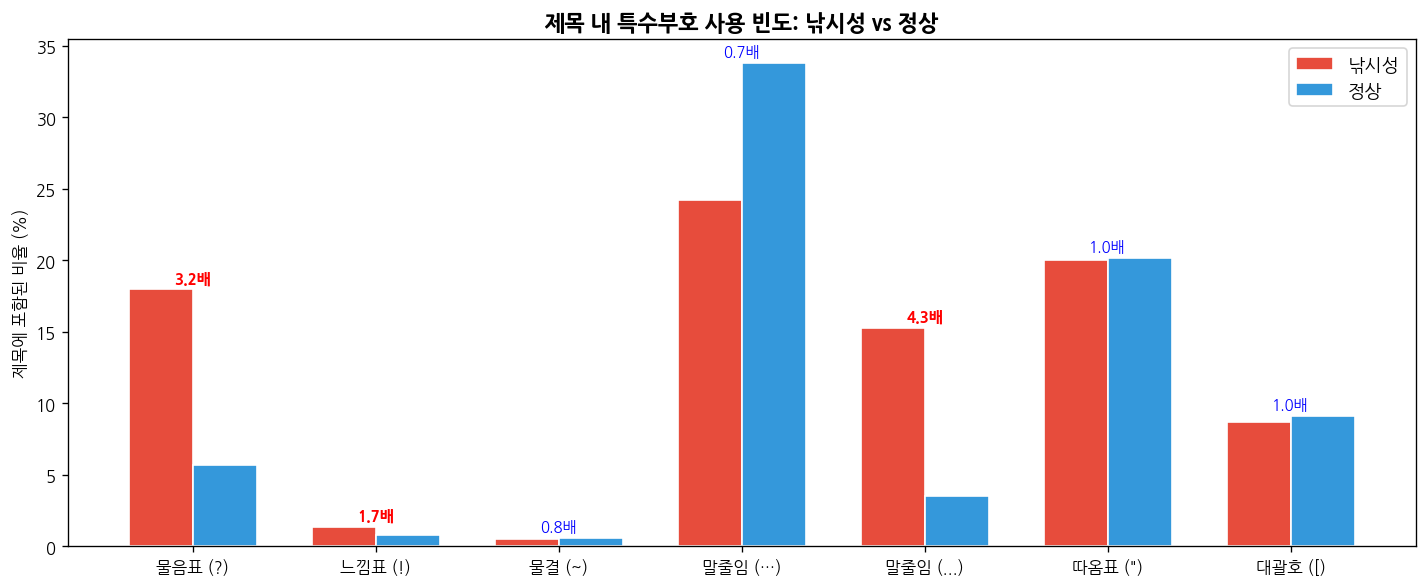

       부호    낚시성(%)     정상(%)       배율
  물음표 (?) 17.951684  5.651342 3.176534
  느낌표 (!)  1.339310  0.774703 1.728804
   물결 (~)  0.496852  0.591692 0.839714
  말줄임 (…) 24.186285 33.769763 0.716211
말줄임 (...) 15.264166  3.518501 4.338259
  따옴표 (") 19.985628 20.127145 0.992969
  대괄호 ([)  8.690802  9.085217 0.956587


In [6]:
# 제목 내 특수부호 빈도 비교
symbols = {
    '물음표 (?)': r'\?',
    '느낌표 (!)': r'!',
    '물결 (~)': r'~',
    '말줄임 (…)': '…',
    '말줄임 (...)': r'\.\.\.',
    '따옴표 (")': '"',
    '대괄호 ([)': r'\[',
}

results = []
for name, pattern in symbols.items():
    cb_rate = df_cb['title_clean'].str.contains(pattern, na=False, regex=True).mean() * 100
    nc_rate = df_nc['title_clean'].str.contains(pattern, na=False, regex=True).mean() * 100
    results.append({'부호': name, '낚시성(%)': cb_rate, '정상(%)': nc_rate, '배율': cb_rate/nc_rate if nc_rate > 0 else 0})

df_sym = pd.DataFrame(results)

# 그래프
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(df_sym))
width = 0.35
bars1 = ax.bar(x - width/2, df_sym['낚시성(%)'], width, label='낚시성', color='#e74c3c', edgecolor='white')
bars2 = ax.bar(x + width/2, df_sym['정상(%)'], width, label='정상', color='#3498db', edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(df_sym['부호'], fontsize=10)
ax.set_ylabel('제목에 포함된 비율 (%)')
ax.set_title('제목 내 특수부호 사용 빈도: 낚시성 vs 정상', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)

# 배율 표시
for i, row in df_sym.iterrows():
    max_val = max(row['낚시성(%)'], row['정상(%)'])
    if row['배율'] > 1:
        ax.text(i, max_val + 0.5, f"{row['배율']:.1f}배", ha='center', fontsize=9, color='red', fontweight='bold')
    elif row['배율'] > 0:
        ax.text(i, max_val + 0.5, f"{row['배율']:.1f}배", ha='center', fontsize=9, color='blue')

plt.tight_layout()
plt.show()

print(df_sym.to_string(index=False))

### 해석

- **물음표(?)**: 낚시성 18.0% vs 정상 5.7% → **3.2배 차이**. 유형 11(의문 유발형 부호)의 핵심 신호.
- **마침표 3개(...)**: 낚시성에서 **4.3배** 더 많이 출현 — 이번 EDA의 가장 주목할 발견. 의도적 말줄임으로 클릭을 유도하는 패턴.
- **느낌표(!)**: 1.7배로 낚시성이 더 높음. 선정/과장형(유형 13, 15)의 부수적 신호.
- **유니코드 말줄임(…)**: 오히려 정상 기사에서 더 많음(0.7배) — 형태가 비슷해도 `...`과 `…`은 완전히 다른 분포.
- **따옴표("), 대괄호([)**: 낚시/정상 차이 거의 없음(약 1.0배).
- 물음표와 `...`의 압도적 차이가 **구두점 유지 결정**의 직접적 근거. 수업 자료 p.60 "Can't just blindly remove punctuation"에 정확히 해당하는 사례.
- 특히 `...`(3점)과 `…`(유니코드)의 역전 현상은 토크나이저가 이 둘을 구분하여 처리해야 함을 시사.

## 6. 출처 클래스별 분포

3개 출처 클래스(NonClickbait_Auto, Clickbait_Auto, Clickbait_Direct)의 건수를 확인한다.

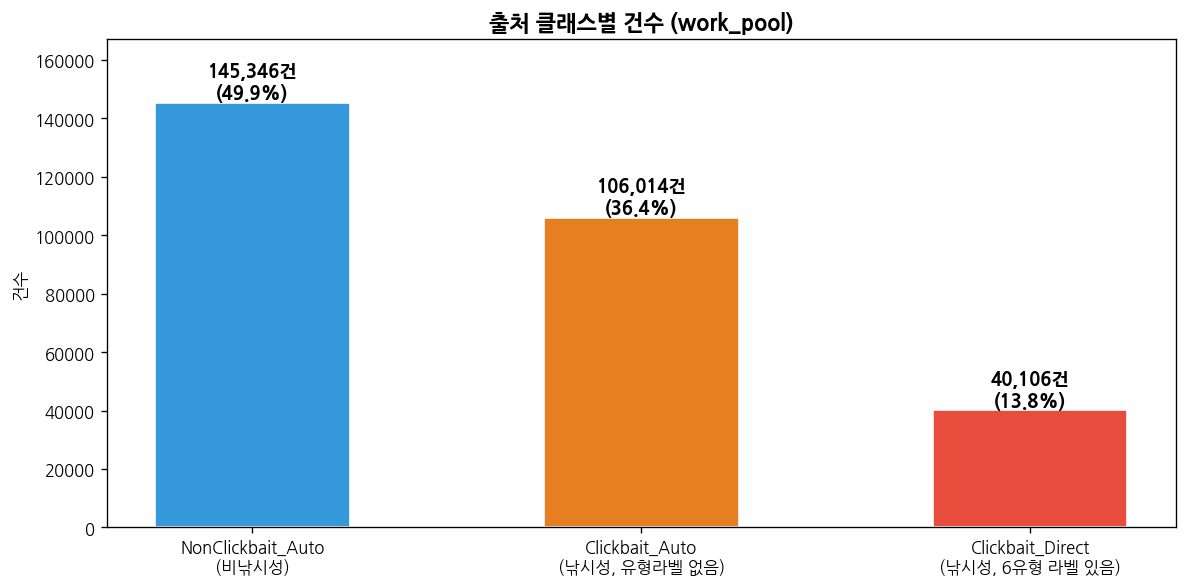

In [7]:
# 출처 클래스별 분포
class_counts = df['source_class'].value_counts()
class_labels = {
    'nonclickbait_auto': 'NonClickbait_Auto\n(비낚시성)',
    'clickbait_auto': 'Clickbait_Auto\n(낚시성, 유형라벨 없음)',
    'clickbait_direct': 'Clickbait_Direct\n(낚시성, 6유형 라벨 있음)'
}

fig, ax = plt.subplots(figsize=(10, 5))
colors_3 = ['#3498db', '#e67e22', '#e74c3c']
labels = [class_labels[c] for c in class_counts.index]
bars = ax.bar(labels, class_counts.values, color=colors_3, edgecolor='white', width=0.5)

for bar, v in zip(bars, class_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 1500,
            f'{v:,}건\n({v/len(df)*100:.1f}%)', ha='center', fontsize=11, fontweight='bold')

ax.set_title('출처 클래스별 건수 (work_pool)', fontsize=13, fontweight='bold')
ax.set_ylabel('건수')
ax.set_ylim(0, max(class_counts.values) * 1.15)

plt.tight_layout()
plt.show()

### 해석

- NonClickbait_Auto가 가장 많고, Clickbait_Direct가 가장 적음.
- 이진 분류에서는 Auto + Direct = 낚시성으로 합쳐지므로 약 1:1 균형.
- 다중 분류는 Direct 40,106건만 사용 — 충분한 양이지만 이진 대비 데이터가 적어 과적합 주의.

## 7. 결측값 및 중복 확인

학습 전에 빈 문자열, null, 중복 기사가 있는지 확인한다. 있으면 전처리에서 제외해야 한다.

In [8]:
# 결측값 확인
print('=== 결측값 / 빈 문자열 ===')
for col in ['newTitle', 'newsContent', 'title_clean', 'content_clean']:
    null_cnt = df[col].isnull().sum()
    empty_cnt = (df[col] == '').sum()
    print(f'  {col}: null={null_cnt}, 빈문자열={empty_cnt}')

# 중복 확인 (newsID 기준)
print(f'\n=== 중복 확인 ===')
dup_id = df['newsID'].duplicated().sum()
print(f'  newsID 중복: {dup_id:,}건')

# 제목+본문 해시 기준 중복
df['text_hash'] = (df['title_clean'] + df['content_clean']).apply(hash)
dup_text = df['text_hash'].duplicated().sum()
print(f'  제목+본문 동일: {dup_text:,}건')

if dup_text > 0:
    print(f'  → 전체의 {dup_text/len(df)*100:.2f}%')
# 중복 샘플 보기
    dup_mask = df['text_hash'].duplicated(keep=False)
    print(f'\n  [중복 샘플]')
    print(df[dup_mask].head(4)[['newsID','source_class','title_clean']].to_string())

df.drop(columns=['text_hash'], inplace=True)

=== 결측값 / 빈 문자열 ===
  newTitle: null=0, 빈문자열=0
  newsContent: null=0, 빈문자열=0
  title_clean: null=0, 빈문자열=0
  content_clean: null=0, 빈문자열=0

=== 중복 확인 ===
  newsID 중복: 0건
  제목+본문 동일: 251건
  → 전체의 0.09%

  [중복 샘플]
               newsID       source_class                            title_clean
146284  ET_M03_278842  nonclickbait_auto     안재욱, 딸 출산에 감사인사 \"오늘 드디어 아빠가 됐어요\"
146346  ET_M03_285576  nonclickbait_auto  2NE1 씨엘·워너 송민호 열애설…YG 측 \"어이없다\" 공식입장
146470  ET_M03_279786  nonclickbait_auto      복면가왕 파리넬리가 KCM? 천상지희 다나 '눈꽃여왕' 깜짝
146511  ET_M03_282340  nonclickbait_auto   이주노 억대 사기 혐의 기소, 돌잔치 업체 개업할려고 10억원을…


### 해석

- **결측값(null)**: 전 컬럼 0건. **빈 문자열**: 전 컬럼 0건 — 데이터 품질 양호.
- **newsID 중복**: 0건 — 기사별 고유 식별이 보장됨.
- **제목+본문 텍스트 동일**: **251건(0.09%)** 발견. 서로 다른 newsID인데 제목과 본문이 완전히 같은 기사.
- 251건은 전체 291,466건 대비 극소수이므로 학습 결과에 큰 영향은 없으나, K-Fold 분할 시 동일 텍스트가 train/val에 동시에 들어가면 data leakage가 발생할 수 있음.
- **권장**: 추후 학습 단계에서 deduplication(중복 제거) 여부를 결정. 제거하더라도 251건 빠지는 것은 영향 미미.

## 8. 제목-본문 길이 비율

제목 대비 본문이 비정상적으로 짧거나 긴 기사가 있는지 확인한다. 낚시성 기사는 과장된 제목에 비해 본문이 빈약할 수 있다.

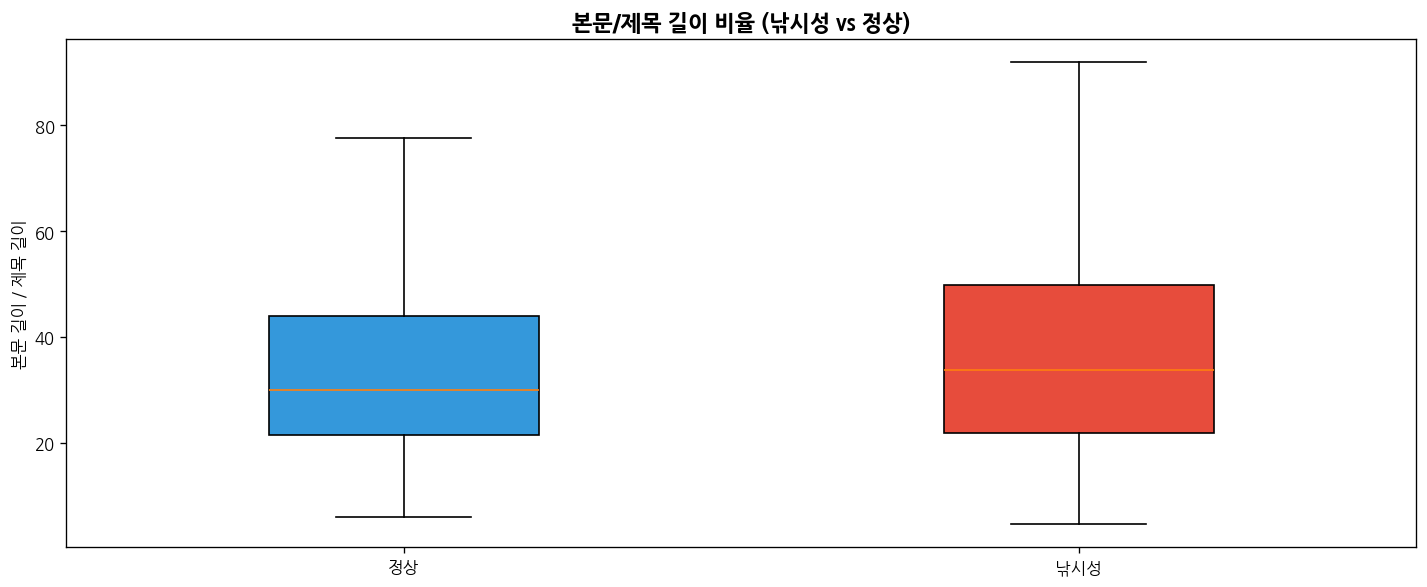

정상 — 중위 비율: 30.1
낚시 — 중위 비율: 33.8


In [9]:
# 제목 대비 본문 길이 비율
df['body_title_ratio'] = df['body_len'] / df['title_len'].clip(lower=1)

fig, ax = plt.subplots(figsize=(12, 5))

# 낚시성 vs 정상 boxplot
data_box = [
    df[df['binary_label']==0]['body_title_ratio'].clip(upper=200),
    df[df['binary_label']==1]['body_title_ratio'].clip(upper=200)
]
bp = ax.boxplot(data_box, labels=['정상', '낚시성'], patch_artist=True,
                widths=0.4, showfliers=False)
bp['boxes'][0].set_facecolor('#3498db')
bp['boxes'][1].set_facecolor('#e74c3c')

ax.set_title('본문/제목 길이 비율 (낚시성 vs 정상)', fontsize=13, fontweight='bold')
ax.set_ylabel('본문 길이 / 제목 길이')

plt.tight_layout()
plt.show()

print(f'정상 — 중위 비율: {df[df["binary_label"]==0]["body_title_ratio"].median():.1f}')
print(f'낚시 — 중위 비율: {df[df["binary_label"]==1]["body_title_ratio"].median():.1f}')

### 해석

- **정상 기사**: 본문/제목 비율 중위수 **30.1** (본문이 제목의 약 30배 길이).
- **낚시성 기사**: 본문/제목 비율 중위수 **33.8** — 오히려 낚시성이 **더 높음**.
- 이는 초기 가설("낚시성 기사는 제목만 과장되고 본문은 빈약할 것")과 **반대되는 결과**.
- 해석: 낚시성 기사도 본문 분량 자체는 충분하되, **제목과 본문의 의미적 불일치**가 문제. 즉, 양(길이)이 아닌 질(내용 일치도)이 핵심.
- 따라서 길이 비율을 단독 피처로 쓰기보다는, BERT가 제목-본문 간 **의미적 관계**를 학습하도록 하는 것이 더 유효한 전략.

## 9. 낚시성 기사 제목 샘플 (유형별)

실제 낚시성 기사 제목을 유형별로 3건씩 확인하여, 각 유형의 특성을 직관적으로 파악한다.

In [10]:
# 유형별 제목 샘플
TYPE_NAMES_FULL = {
    0: '의문 유발형 (부호) — code 11',
    1: '의문 유발형 (은닉) — code 12',
    2: '선정 표현 사용형 — code 13',
    3: '속어/줄임말 사용형 — code 14',
    4: '사실 과대 표현형 — code 15',
    5: '의도적 주어 왜곡형 — code 16'
}

for type_id, type_name in TYPE_NAMES_FULL.items():
    subset = df_direct[df_direct['type_label'] == type_id]
    samples = subset.sample(n=min(3, len(subset)), random_state=42)
    print(f'\n📌 [{type_name}] ({len(subset):,}건)')
    print('-' * 60)
    for _, row in samples.iterrows():
        print(f'  제목: {row["title_clean"]}')
        print(f'  본문: {row["content_clean"][:80]}...')
        print()


📌 [의문 유발형 (부호) — code 11] (14,863건)
------------------------------------------------------------
  제목: 끈끈한 가족애 보여주며 연예계 금빛 족보 명단 1위에 오른 이들은?
  본문: 한혜진·기성용 부부가 서로 힘이 돼주는 금빛 족보 명단 1위에 올랐다. 지난 2일 방송된 tvN 예능 ‘명단공개2017’에는 ‘가문의 영광! 연...

  제목: 민주당, 임동호 '당직 자격 6개월간 정지' 징계... 그의 반응은?
  본문: ━ 당적 유지되지만…경선 출마시 ‘25% 페널티’ 더불어민주당은 30일 울산시당에서 제명 처분을 받았던 임동호 전 최고위원에 대해 ‘당직 자격 ...

  제목: 로봇이면 다 되는 줄... 로봇에도 유망한 분야가 따로 있다?
  본문: 멜로니 와이즈(Melonee Wise)는 집집마다 가정부 로봇, 젯슨 로지* 같은 자동로봇이 일할 미래를 상상한다. 단, 앞치마와 브루클린 억양...


📌 [의문 유발형 (은닉) — code 12] (11,685건)
------------------------------------------------------------
  제목: 민주당 '이 법안', 야당 강력히 반발... "최근 남북 관계를 무시한 법안"
  본문: 더불어민주당에서 한국 국민의 북한 주민 접촉 절차를 간소화하자는 내용의 법안이 제출돼 야당이 반발하고 있다. 국회 외교통일위원회 소속 이재정 민...

  제목: 'MBN 자본금 충당 회계 조작'... 증권선물위원회, '이것' 부과
  본문: 금융위원회 산하 증권선물위원회가 종편 설립에 필요한 자본금을 편법으로 충당하면서 회계를 조작한 혐의를 산 종합편성채널 MBN에 대해 과징금 70...

  제목: 한국, '포켓몬 고' 미출시 국가인데... '이 지역'에서는 게임 가능?
  본문: 지난 6일 미국, 호주, 뉴질랜드에 출시돼 전 세계적인 신드롬으로 번진 ‘포켓몬 고’는 유럽을 거쳐 지난 22일 ‘포켓몬스터’ 

### 해석

- **유형 11(부호)**: 제목에 `?`, `!` 등 부호가 눈에 띄게 많음. "○○했을까?", "…충격!" 등 부호로 호기심 유발.
- **유형 12(은닉)**: 부호 없이 핵심 정보를 숨기는 패턴 — "이것", "그 사람", "알고 보니" 등 모호한 대명사와 지시어 사용.
- **유형 13(선정)**: "충격", "경악", "소름" 등 자극적이고 감정적인 단어 사용.
- **유형 14(속어)**: 비격식 표현, 줄임말, 인터넷 용어 포함.
- **유형 15(과대)**: "역대 최고", "사상 최대" 등 사실보다 부풀린 표현.
- **유형 16(왜곡)**: 주어를 바꾸거나 생략하여 오해를 유도하는 패턴.

이 샘플을 통해 각 유형의 언어적 특징이 뚜렷이 다름을 확인. 특히 유형 11(부호)과 12(은닉)는 둘 다 "의문 유발"이지만 수단이 완전히 다르므로, 모델이 **부호 존재 여부 + 어휘 패턴**을 동시에 학습해야 구분 가능.

## 10. EDA 요약 및 전처리 시사점

| 항목 | 결과 | 시사점 |
|---|---|---|
| 이진 분류 균형 | 145,346 vs 146,120 (49.9:50.1) | class_weight 불필요 |
| 다중 분류 불균형 | 최대 14,863 / 최소 2,080 (7.1배) | class_weight='balanced' 필수 |
| 제목 길이 | 평균 32.0자, 정상 31.4 vs 낚시 32.6 | 길이 차이 미미 → 내용이 핵심 |
| 본문 길이 | 50.0%가 1000자 초과, 21.7%가 1500자 초과 | head truncation 전략 필요 |
| 결측값 | null/빈문자열 0건 | 별도 처리 불필요 |
| 텍스트 중복 | 251건 (0.09%) | K-Fold 시 leakage 주의, 제거 권장 |
| 물음표 빈도 | 낚시성 3.2배 높음 | 구두점 유지 결정 근거 |
| ... (3점) 빈도 | 낚시성 4.3배 높음 | EDA 최대 발견, 구두점 유지 추가 근거 |
| 본문/제목 비율 | 정상 30.1 vs 낚시 33.8 | 가설 반대 → 길이가 아닌 의미적 불일치 |
| 구두점 처리 | 전체 유지 | 수업 p.60 "blindly remove 금지" 준수 |
